In [1]:
import netCDF4 as nc
import numpy as np
import os

regions = list(zip(
    [-180, -150, -90, -60, -30, 0, 30, 120, 150, -180, -150, -120, -90, -60, -30, 30, 60, 90, 120, 150,
     -180, -150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150,
     -180, -150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150],

    [-150, -120, -60, -30, 0, 30, 60, 150, 180, -150, -120, -90, -60, -30, 0, 60, 90, 120, 150, 180,
     -150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150, 180,
     -150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150, 180],

    [30, 30, 30, 30, 30, 30, 30, 30, 30,
     0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
     -30, -30, -30, -30, -30, -30, -30, -30, -30, -30, -30, -30,
     -60, -60, -60, -60, -60, -60, -60, -60, -60, -60, -60, -60],

    [60, 60, 60, 60, 60, 60, 60, 60, 60,
     30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,
     0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
     -30, -30, -30, -30, -30, -30, -30, -30, -30, -30, -30, -30],

    [f"{i:02d}" for i in range(1, 45)]
))

netcdf_path = './data/SST_20240101.nc'
save_path = './data/regions'
os.makedirs(save_path, exist_ok=True)

dataset = nc.Dataset(netcdf_path)

lon = dataset.variables['lon'][:]
lat = dataset.variables['lat'][:]

In [2]:
# 1. CCA
import functions.CCA as CCA

for beginLon, endLon, beginLat, endLat, region_name in regions:
    lon_index = np.where((lon >= beginLon) & (lon < endLon))[0]
    lat_index = np.where((lat >= beginLat) & (lat < endLat))[0]

    data_temp = dataset.variables['analysed_sst'][:, lat_index, lon_index]
    data_temp = data_temp[0]
    data_temp = np.array(data_temp)
    data_temp[np.where(data_temp > 100)] = np.nan
    data_temp[np.where(data_temp < -100)] = np.nan

    marked_matrix = CCA.sied2_multiscale(data_temp)
    
    marked_matrix = marked_matrix.astype(np.float32)

    output_path = os.path.join(save_path, region_name, 'cca.npy')
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    np.save(output_path, marked_matrix)

In [ ]:
# 2. CCAIM
import functions.CCAIM as CCAIM

for beginLon, endLon, beginLat, endLat, region_name in regions:
    lon_index = np.where((lon >= beginLon) & (lon < endLon))[0]
    lat_index = np.where((lat >= beginLat) & (lat < endLat))[0]

    data_temp = dataset.variables['analysed_sst'][:, lat_index, lon_index]
    data_temp = data_temp[0]
    data_temp = np.array(data_temp)
    data_temp[np.where(data_temp > 100)] = np.nan
    data_temp[np.where(data_temp < -100)] = np.nan

    marked_matrix = CCAIM.sied2_multiscale(data_temp)
    
    marked_matrix = marked_matrix.astype(np.float32)

    output_path = os.path.join(save_path, region_name, 'ccaim.npy')
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    np.save(output_path, marked_matrix)

In [ ]:
# 3. Entropy
import functions.Entropy as Entropy

for beginLon, endLon, beginLat, endLat, region_name in regions:
    lon_index = np.where((lon >= beginLon) & (lon < endLon))[0]
    lat_index = np.where((lat >= beginLat) & (lat < endLat))[0]

    data_temp = dataset.variables['analysed_sst'][:, lat_index, lon_index]
    data_temp = data_temp[0]
    data_temp = np.array(data_temp)
    data_temp[np.where(data_temp > 100)] = np.nan
    data_temp[np.where(data_temp < -100)] = np.nan

    marked_matrix = Entropy.get_front_zone(data_temp)
    
    marked_matrix = marked_matrix.astype(np.float32)

    output_path = os.path.join(save_path, region_name, 'entropy.npy')
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    np.save(output_path, marked_matrix)

c:\Users\codeAI\Desktop\GlobalFrontDB\Entropy.py:109: RuntimeWarning: All-NaN slice encountered
  js_total = np.nanmax(np.stack([js_lr, js_ul]), axis=0)


In [ ]:
# 4. Canny and GBM
import functions.CannyGBM as CannyGBM

for beginLon, endLon, beginLat, endLat, region_name in regions:
    canny_matrix, gradient_direction, gbm_matrix, lon_extracted, lat_extracted = CannyGBM.get_gradient_front_zone(dataset, lon, lat, beginLon, endLon, beginLat, endLat)
    
    gbm_matrix = gbm_matrix.astype(np.float32)

    output_path = os.path.join(save_path, region_name)
    
    np.save(os.path.join(output_path, 'gbm.npy'), gbm_matrix)
    np.save(os.path.join(output_path, 'canny.npy'), canny_matrix)
    np.save(os.path.join(output_path, 'gradient_direction.npy'), gradient_direction)
    np.save(os.path.join(output_path, 'lon_extracted.npy'), lon_extracted)
    np.save(os.path.join(output_path, 'lat_extracted.npy'), lat_extracted)

c:\Users\codeAI\Desktop\GlobalFrontDB\bayesian_plus.py:33: RuntimeWarning: All-NaN slice encountered
  v_max  = np.nanmax(neighbor_vector, axis=2)
c:\Users\codeAI\Desktop\GlobalFrontDB\bayesian_plus.py:34: RuntimeWarning: All-NaN slice encountered
  v_min  = np.nanmin(neighbor_vector, axis=2)
c:\Users\codeAI\Desktop\GlobalFrontDB\bayesian_plus.py:35: RuntimeWarning: Mean of empty slice
  v_mean = np.nanmean(neighbor_vector, axis=2)
c:\Users\codeAI\Desktop\GlobalFrontDB\bayesian_plus.py:33: RuntimeWarning: All-NaN slice encountered
  v_max  = np.nanmax(neighbor_vector, axis=2)
c:\Users\codeAI\Desktop\GlobalFrontDB\bayesian_plus.py:34: RuntimeWarning: All-NaN slice encountered
  v_min  = np.nanmin(neighbor_vector, axis=2)
c:\Users\codeAI\Desktop\GlobalFrontDB\bayesian_plus.py:35: RuntimeWarning: Mean of empty slice
  v_mean = np.nanmean(neighbor_vector, axis=2)


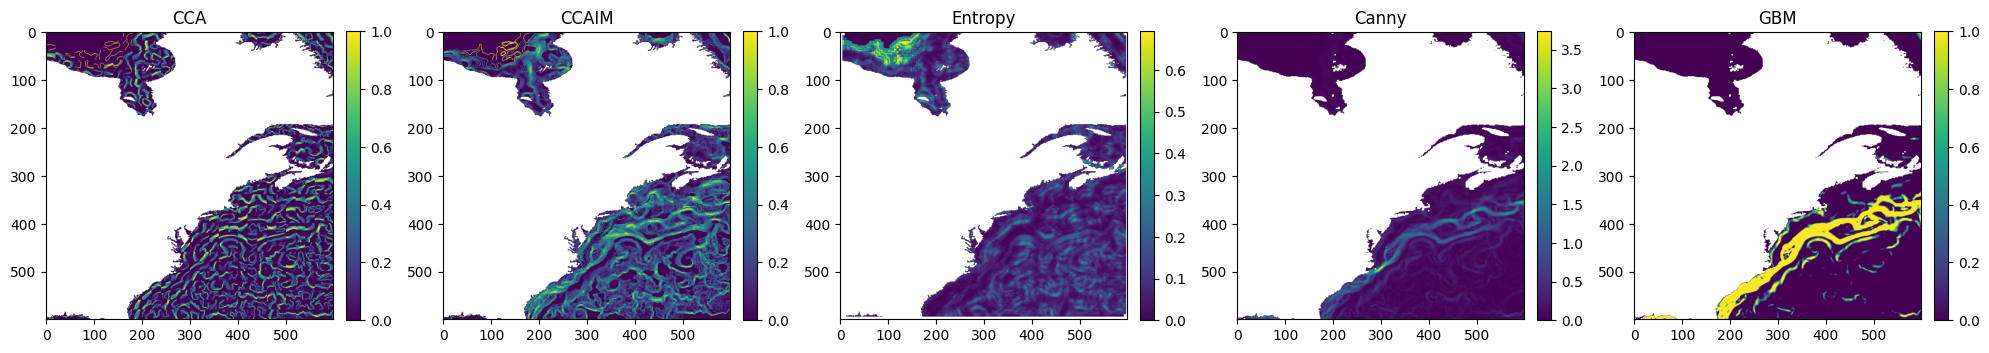

In [3]:
# 5. plot one region to show the results
import matplotlib.pyplot as plt

region_name = '03'

cca_matrix = np.load(os.path.join(save_path, region_name, 'cca.npy'))
ccaim_matrix = np.load(os.path.join(save_path, region_name, 'ccaim.npy'))
entropy_matrix = np.load(os.path.join(save_path, region_name, 'entropy.npy'))
canny_matrix = np.load(os.path.join(save_path, region_name, 'canny.npy'))
gbm_matrix = np.load(os.path.join(save_path, region_name, 'gbm.npy'))

plt.figure(figsize=(20, 4))
plt.subplot(1, 5, 1)
plt.imshow(np.flipud(cca_matrix), cmap='viridis')
plt.title('CCA')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(1, 5, 2)
plt.imshow(np.flipud(ccaim_matrix), cmap='viridis')
plt.title('CCAIM')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(1, 5, 3)
plt.imshow(np.flipud(entropy_matrix), cmap='viridis')
plt.title('Entropy')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(1, 5, 4)
plt.imshow(np.flipud(canny_matrix), cmap='viridis')
plt.title('Canny')
plt.colorbar(fraction=0.046, pad=0.04)
plt.subplot(1, 5, 5)
plt.imshow(np.flipud(gbm_matrix), cmap='viridis')
plt.title('GBM')
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()